# HW 2: Wrangling

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

In [31]:
import pandas as pd
import numpy as np

In [34]:
#Q1.1
df = pd.read_csv('/content/wrangling/assignment/data/airbnb_hw.csv')

df['Price_clean'] = df['Price'].str.replace(',', '').astype(float)

df["Price_clean"].isna().sum()

#The 'Price' column was categorical due to the commas in numbers above 999, so we removed those and change the data type of the column to float. This left us with zero missing values.

np.int64(0)

In [59]:
#Q1.2
df2 = pd.read_csv('/content/wrangling/assignment/data/mn_police_use_of_force.csv')
df2.head()

df2['subject_injury'].isna().sum()

df2 = df2.dropna(subset=['subject_injury'])

#In the 'subject_injury' column of the data set, there appear to be 9848 missing values, around 76% of the obsservations. This is certainly a concern we must take into account when drawing conclusions from this data.
df2.head()
pd.crosstab(df2["subject_injury"], df2["force_type"], dropna=False)

#It appears that most of the missing data is when there is not a reported injury, but there is missing data in pretty much every category of 'force_type'.

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal Projectile,Police K9 Bite,Taser
subject_injury,,,,,,,,,
No,0,1093,131,2,33,34,1,2,150
Yes,2,1286,41,0,44,40,2,44,172


In [72]:
#Q1.3
df3 = pd.read_csv('/content/wrangling/assignment/data/pretrial_data.csv')
df3.head()

df3['released'].isna().sum()

df3['released'] = df3['released'].replace('NA',np.nan).astype(float)
df3.head()

,Unnamed: 0,case_type,age,sex,race,is_poor,bond,bond_type,prior_F,prior_M,gini,released,sentence_type,sentence,bond_NA,held_wo_bail,sentence_NA
0,0,F,31.0,M,W,NaN,NaN,7,0.0,0.0,0.44,NaN,NaN,NaN,True,False,True
1,1,F,60.0,M,B,NaN,NaN,7,13.0,21.0,0.44,0.0,0.0,60.000000,True,False,False
2,2,M,27.0,M,W,NaN,NaN,7,0.0,0.0,0.44,0.0,1.0,12.000000,True,False,False
3,3,M,27.0,M,B,0.0,NaN,7,0.0,9.0,0.44,0.0,1.0,0.985626,True,False,False
4,4,F,28.0,F,W,0.0,NaN,7,0.0,0.0,0.44,1.0,4.0,0.000000,True,False,True


In [79]:
#Q1.4
missing_values = ["", "na", "n/a", "none"]

df3["sentence_clean"] = df3["sentence"].astype(str).str.strip().str.lower()
df3["sentence_clean"] = df3["sentence_clean"].replace(missing_values, np.nan).astype(float)

df3.head()

#I replaced any missing valued with np.nan and made sure all sentences were of the float variable type in order to compare sentences.

,Unnamed: 0,case_type,age,sex,race,is_poor,bond,bond_type,prior_F,prior_M,gini,released,sentence_type,sentence,bond_NA,held_wo_bail,sentence_NA,sentence_clean
0,0,F,31.0,M,W,NaN,NaN,7,0.0,0.0,0.44,NaN,NaN,NaN,True,False,True,NaN
1,1,F,60.0,M,B,NaN,NaN,7,13.0,21.0,0.44,0.0,0.0,60.000000,True,False,False,60.000000
2,2,M,27.0,M,W,NaN,NaN,7,0.0,0.0,0.44,0.0,1.0,12.000000,True,False,False,12.000000
3,3,M,27.0,M,B,0.0,NaN,7,0.0,9.0,0.44,0.0,1.0,0.985626,True,False,False,0.985626
4,4,F,28.0,F,W,0.0,NaN,7,0.0,0.0,0.44,1.0,4.0,0.000000,True,False,True,0.000000


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

In [148]:
#Q2.1
sharks = pd.read_excel('/content/wrangling/assignment/data/GSAF5.xls')
sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th January,2026.0,Unprovoked,Australia,NSW,North Steyne,Surfing,Andre de Ruyter,M,27,...,5m shark species not determined,9 News: Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18th January,2026.0,Unprovoked,Australia,NSW,Nielsen Park Vaucluse Sydney Harbour,Jumping off rocks,Nico Antic,M,12,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10th January,2026.0,Unprovoked,Australia,NSW,Avalon Beach,Surfing,Paul Stanton,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
#Q2.2
sharks = sharks.dropna(axis=1, how='all')
sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th January,2026.0,Unprovoked,Australia,NSW,North Steyne,Surfing,Andre de Ruyter,M,27,...,5m shark species not determined,9 News: Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18th January,2026.0,Unprovoked,Australia,NSW,Nielsen Park Vaucluse Sydney Harbour,Jumping off rocks,Nico Antic,M,12,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10th January,2026.0,Unprovoked,Australia,NSW,Avalon Beach,Surfing,Paul Stanton,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year'>

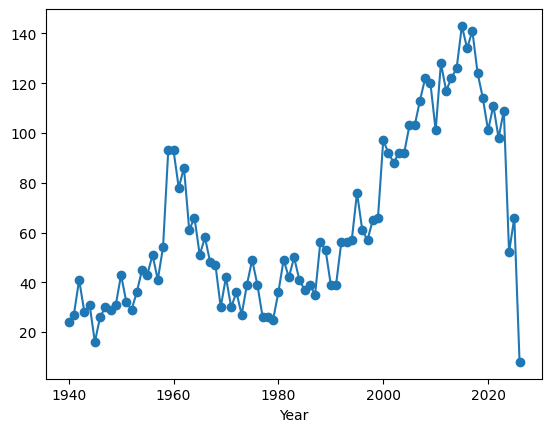

In [150]:
#Q2.3
sharks = sharks.dropna(subset=["Year"])
sharks['Year'].astype(int)

sharks["Year"].describe()
#The value range from 0 to 2026

sharks = sharks[sharks["Year"] >= 1940]

import matplotlib.pyplot as plt

attacks_per_year = sharks.groupby("Year").size()
attacks_per_year.plot(kind="line", marker="o")

#Attacks have increased over time

<Axes: >

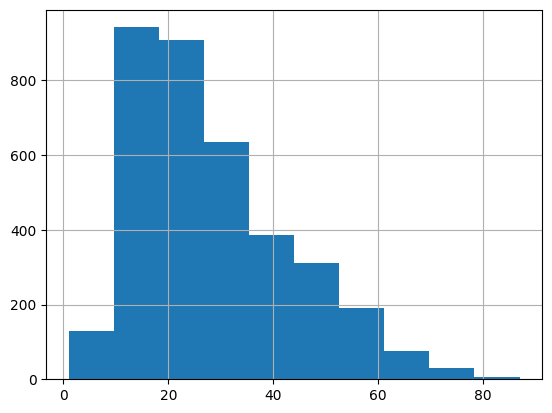

In [151]:
#Q2.4
sharks['Age_clean'] = sharks['Age'].apply(lambda x: int(x) if str(x).isdigit() else np.nan)
sharks = sharks.dropna(subset=['Age_clean'])
sharks['Age_clean'] = sharks['Age_clean'].astype(int)
sharks['Age_clean'].hist()

In [152]:
#Q2.5
sharks['Sex'] = sharks['Sex'].str.upper().str.strip()

sum(sharks['Sex'] == 'M')/len(sharks)
#about 83.5% of vicitms are male

0.8353624792473713

In [153]:
#Q2.6
sharks['Type'] = sharks['Type'].str.capitalize()

sharks['Type'] = np.where(
    np.isin(sharks['Type'], ['Provoked', 'Unprovoked']),
    sharks['Type'],
    'Unknown'
)

sum(sharks['Type'] == 'Unprovoked')/len(sharks)
#about 83.3% of shark attacks are unprovoked

0.832595462091865

In [154]:
#Q2.7
sharks['Fatal Y/N'].str.strip().unique()

sharks['Fatal Y/N'] = np.where(
    np.isin(sharks['Fatal Y/N'], ['Y', 'N']),
    sharks['Fatal Y/N'],
    'Unknown'
)

sharks['Fatal Y/N'].unique()

array(['N', 'Y', 'Unknown'], dtype=object)

In [155]:
#Q2.8
pd.crosstab(sharks["Sex"], sharks["Type"], dropna=False)
#sharks are more likely to launch unprovoked attacks on men

Type,Provoked,Unknown,Unprovoked
Sex,,,
F,21,49,492
LLI,0,0,1
M,267,258,2494
NaN,5,5,22


In [156]:
pd.crosstab(sharks["Fatal Y/N"], sharks["Type"], dropna=False)
#attacks seem more likely to be fatal when unprovoked and less likely to be fatal when provoked

Type,Provoked,Unknown,Unprovoked
Fatal Y/N,,,
N,281,87,2493
Unknown,4,195,23
Y,8,30,493


In [157]:
pd.crosstab(sharks["Sex"], sharks["Fatal Y/N"], dropna=False)
#attacks seem more likely to be fatal for men and less likely to be fatal for women

#Overall, my opinion on sharks is that they can be dangerous, so it is best to keep your distance to ensure you are not attacked.

Fatal Y/N,N,Unknown,Y
Sex,,,
F,448,36,78
LLI,1,0,0
M,2391,182,446
NaN,21,4,7


In [165]:
#Q2.9
sharks['Species '].value_counts()

sharks['Species '].str.contains('White shark', case=False, na=False).sum() / len(sharks)
#about 12.5% of attacks are by white sharks

np.float64(0.1253458771444383)

**Q3.** Open the "tidy_data.pdf" document in the repo, which is a paper called Tidy Data by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  
  The paper introduces “tidy data”, a standardized way of organizing datasets that makes data manipulation, visualization, and modeling easier and more consistent
  
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?

tidy data standard is intended to reduce friction in data analysis by providing a consistent data structure that works seamlessly with common data analysis tools

  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."

Tidy datasets follow the same structural rules, while messy datasets can violate those rules in many different ways.

Identifying variables and observations is straightforward in a specific dataset, but difficult to formalize universally across all possible datasets

  4. Read Section 2.2. How does Wickham define values, variables, and observations?

Values - individual measurements

Variables - attributes measured across observations

Observations - all values measured on a single unit

  5. How is "Tidy Data" defined in section 2.3?

A dataset is tidy if each variable is a column, each observation is a row, and each type of observational unit forms a table

  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?

- Column headers are values, not variable names
- Multiple variables stored in one column
- Variables stored in both rows and columns
- Multiple observational units in one table
- The same observational unit stored in multiple tables

Table 4 is messy because column names represent values of a variable rather than variable names, violating tidy data principles. Melting transforms data from wide format to long format, turning columns into rows so that variables and values are properly separated.

  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

Table 11 mixes variables across columns and rows, while Table 12 has been melted into a tidy format where each variable has its own column and each observation its own row.

  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?

Tools work best with tidy data, but data must already be tidy to easily use those tools, creating a circular dependency. Wickham hopes for better tools, theory, and shared practices for data wrangling that make it easier to transform messy data into tidy data efficiently and systematically.